In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print(tf.__version__)

2.17.1


# ****Data Preprocessing****

 ****Training Image Preprocessing****

In [3]:
train_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

training_set=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
)

Found 70295 files belonging to 38 classes.


****Validation Image Preprocessing****

In [4]:
val_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

validation_set=tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
)

Found 17572 files belonging to 38 classes.


# Building Model

In [5]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [6]:
model = Sequential()

# Building Convolutional Layers

In [7]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [9]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Dropout(0.3)) #To avoid overfitting

In [13]:
model.add(Flatten())

In [14]:
model.add(Dense(units=1500, activation='relu'))

In [15]:
model.add(Dropout(0.45)) #To avoid overfitting

****Output Layer****

In [16]:
model.add(Dense(units=38,activation='softmax'))

# Compiling Model

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [19]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - accuracy: 0.3476 - loss: 2.3333 - val_accuracy: 0.8463 - val_loss: 0.5060
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 127s 58ms/step - accuracy: 0.8312 - loss: 0.5399 - val_accuracy: 0.8791 - val_loss: 0.3689
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 0.9037 - loss: 0.3050 - val_accuracy: 0.9347 - val_loss: 0.2067
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 0.9330 - loss: 0.2032 - val_accuracy: 0.9483 - val_loss: 0.1597
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - accuracy: 0.9519 - loss: 0.1487 - val_accuracy: 0.9546 - val_loss: 0.1435
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - accuracy: 0.9608 - loss: 0.1184 - val_accuracy: 0.9561 - val_loss: 0.1422
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 0.9702 - loss: 0.0904 - val_accuracy: 0.9482 - val_loss: 0.1724
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 

# Model Evaluation

In [20]:
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9827 - loss: 0.0505


In [21]:
print(train_loss,train_acc)

0.04572214558720589 0.9843943119049072


In [22]:
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9567 - loss: 0.1544


In [23]:
print(val_loss,val_acc)

0.14180955290794373 0.9594810009002686


# Saving Model

In [24]:
model.save("Smart_Farming_DL_Model.h5")

In [25]:
training_history.history

{'accuracy': [0.5623301863670349,
  0.8544277548789978,
  0.9131801724433899,
  0.9386158585548401,
  0.955743670463562,
  0.9642506837844849,
  0.97134929895401,
  0.9740521907806396,
  0.9798136353492737,
  0.9826303720474243],
 'loss': [1.4992438554763794,
  0.4618275761604309,
  0.2725771367549896,
  0.18709653615951538,
  0.1367085874080658,
  0.1080547422170639,
  0.08671438694000244,
  0.07767079025506973,
  0.06174197047948837,
  0.056613143533468246],
 'val_accuracy': [0.8462895750999451,
  0.8791258931159973,
  0.9347257018089294,
  0.9483268857002258,
  0.9545868635177612,
  0.9560664892196655,
  0.9482130408287048,
  0.9601069688796997,
  0.9553835391998291,
  0.9594810009002686],
 'val_loss': [0.5059707164764404,
  0.3688623905181885,
  0.206665500998497,
  0.15969543159008026,
  0.14346130192279816,
  0.1422341912984848,
  0.17241834104061127,
  0.13328784704208374,
  0.14631064236164093,
  0.1418096125125885]}

****Recording History in json****

In [26]:
import json
with open("training_hist_PDD.json","w") as f:
    json.dump(training_history.history,f)

# Accuracy Visualization

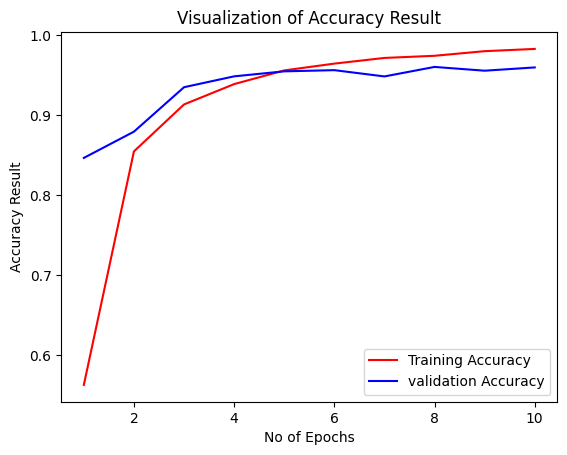

In [27]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='validation Accuracy')
plt.xlabel("No of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

# Some Other Matrics for Model Evaluation

In [28]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [29]:
test_set = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
)

Found 17572 files belonging to 38 classes.


In [30]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step


(array([[1.00000000e+00, 5.36166042e-11, 8.45358939e-13, ...,
         3.95858995e-17, 5.21458131e-15, 1.18555195e-14],
        [9.99978065e-01, 2.25162022e-08, 3.79518861e-10, ...,
         1.36582360e-14, 2.79805638e-13, 1.65385691e-11],
        [1.00000000e+00, 1.12242220e-13, 1.53611363e-13, ...,
         1.10249850e-17, 1.19884469e-15, 1.53060565e-14],
        ...,
        [2.63847277e-10, 2.35651321e-12, 3.13842130e-09, ...,
         8.82715068e-10, 2.35669886e-11, 9.99996185e-01],
        [1.09112989e-10, 1.69782686e-13, 5.31516997e-10, ...,
         8.40005704e-11, 3.95527014e-12, 9.99999642e-01],
        [8.36573745e-17, 1.61866325e-17, 4.46947999e-16, ...,
         2.23058351e-19, 1.57774478e-17, 1.00000000e+00]], dtype=float32),
 (17572, 38))

In [31]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [32]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [33]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [34]:
from sklearn.metrics import classification_report

In [35]:
classification_report(Y_true,predicted_categories,target_names=class_name)

'                                                    precision    recall  f1-score   support\n\n                                Apple___Apple_scab       0.97      0.94      0.95       504\n                                 Apple___Black_rot       0.99      0.99      0.99       497\n                          Apple___Cedar_apple_rust       0.99      0.97      0.98       440\n                                   Apple___healthy       0.91      0.97      0.94       502\n                               Blueberry___healthy       0.98      0.97      0.97       454\n          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.98       421\n                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       456\nCorn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.96      0.94       410\n                       Corn_(maize)___Common_rust_       1.00      0.97      0.99       477\n               Corn_(maize)___Northern_Leaf_Blight       0.97      

# Visualizing Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix

In [37]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[472,   1,   0, ...,   0,   0,   0],
       [  3, 490,   0, ...,   0,   0,   0],
       [  1,   0, 429, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 489,   0,   0],
       [  0,   0,   0, ...,   0, 447,   0],
       [  0,   0,   0, ...,   0,   0, 478]])

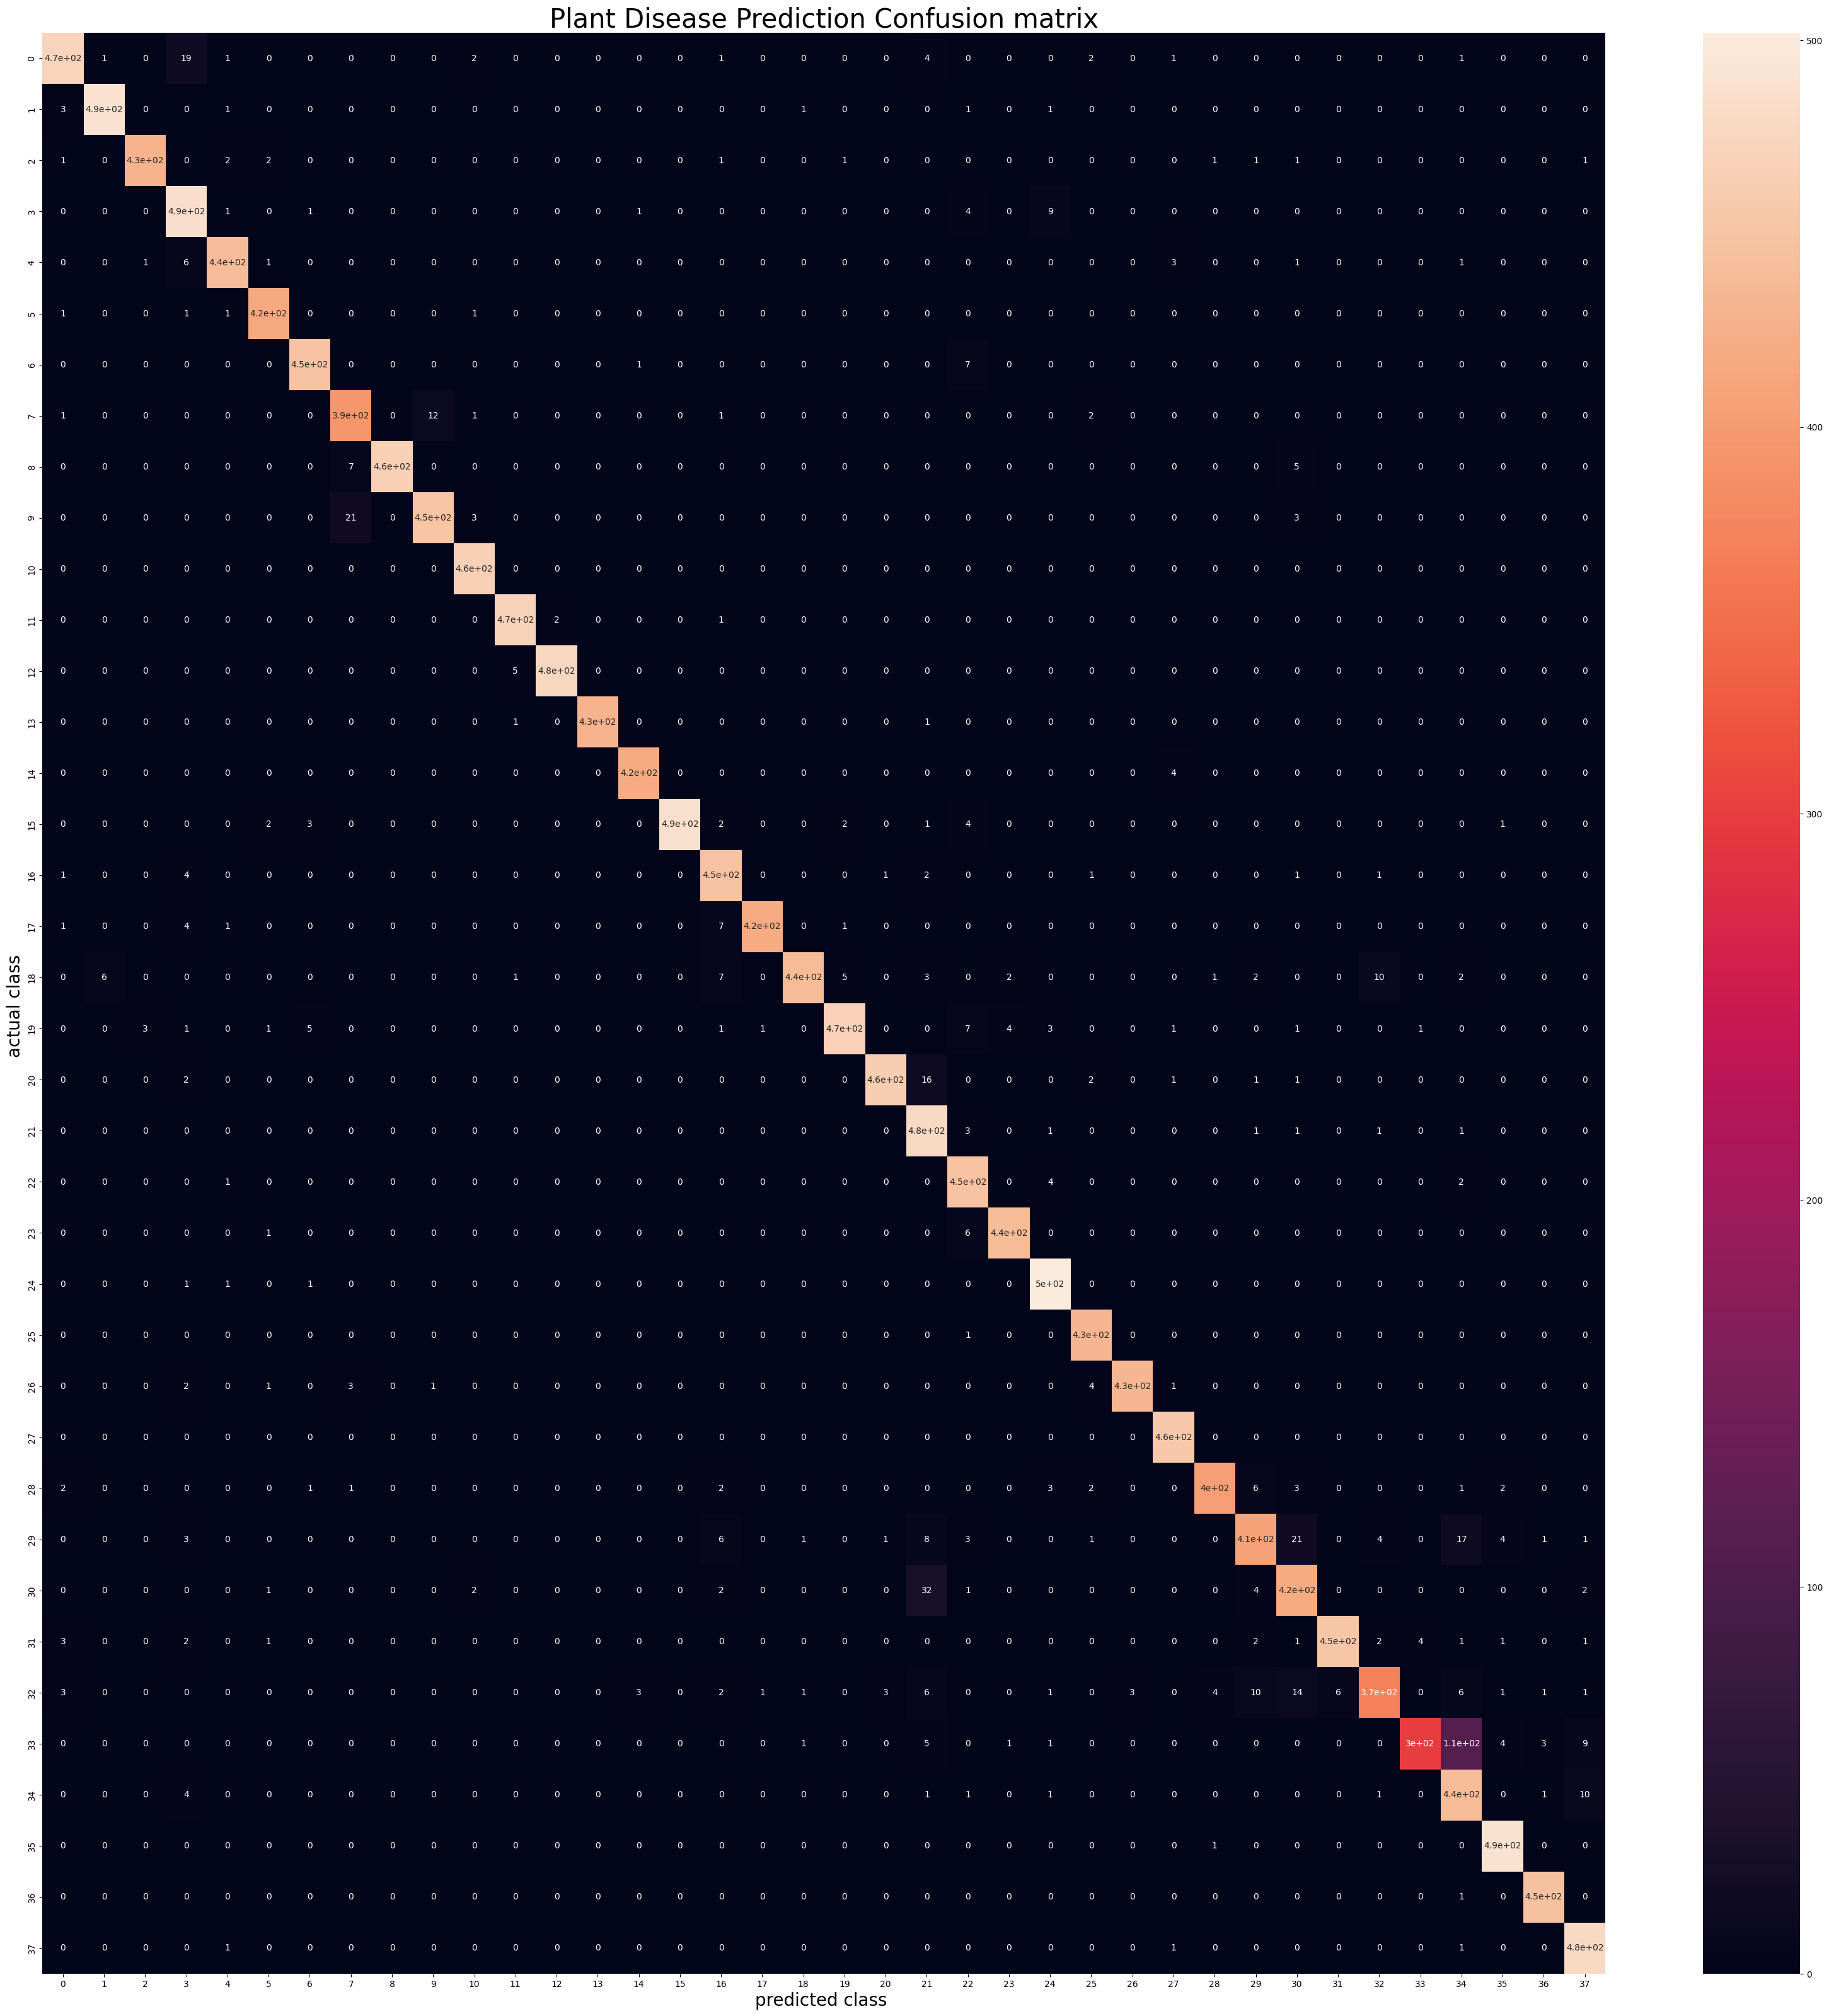

In [38]:
plt.figure(figsize = (40,40))
sns.heatmap(cm,annot=True)
plt.xlabel("predicted class ",fontsize=20)
plt.ylabel("actual class ",fontsize=20)
plt.title("Plant Disease Prediction Confusion matrix",fontsize=30)
plt.show()